# 01_回归算法-局部加权回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 将矩阵伪代码改为 NumPy 运算，并补齐先使用后导入的依赖。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本节，咱们来聊聊局部加权回归\~

**一句话解释：**局部加权回归是一种“更聪明”的回归方法，它在预测一个点时，优先参考“离它近”的数据，而不是把所有数据一视同仁。

我们先看一个普通的线性回归是怎么做的：

> 它会用一条直线去尽量“整体”拟合所有的点，找出一个通用的规律。

但很多时候，数据不是一个“统一的规律”，而是**不同区域有不同的规律**。

**我们举个生活中的例子：**

你想预测一个人的体重和身高的关系。你拿了很多人的数据：

- 小孩子：身高增加，体重增加得很慢
- 青少年：身高和体重关系更强
- 成年人：身高变化不大，但体重差异很大

这时候，如果你只用“一条线”来表示全部人群的身高和体重关系，肯定就不准了。

## 局部加权回归

它不一次性找一条“全局”的线，而是**在你要预测的点附近，单独找一条最合适的线**！

**怎么做的？**

1. 对于每个你想预测的点（比如身高170cm），
2. 它只重点考虑“身高接近170”的那些人的数据（比如168、169、170、171、172），
3. 离得越近，权重越大；离得远，就“看一眼就不太当回事”。
4. 然后基于这些“本地的点”，找出一条局部的线，预测这个点的值。

这就像你问一个问题，普通回归是问“全班同学”，但局部加权回归只问“坐你周围的人”，因为他们更懂你要问的问题。

### 一个简单例子：

假设有这些数据：

| x（身高） | y（体重） |
|-|-|
| 150 | 50 |
| 160 | 55 |
| 170 | 70 |
| 180 | 80 |
| 190 | 85 |

咱们要预测 **x = 170** 的体重：

- 普通回归：用所有点画一条直线。
- 局部加权回归：会重点看 160、170、180 的点，150 和 190 也看，但权重小。

结果：预测更贴近“当前”这个点的规律，更灵活、更精准。

## 原理详解

### 问题定义：回归基本任务

我们有一个数据集：


$$
\{(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), \dots, (x^{(m)}, y^{(m)})\}
$$


$x^{(i)} \in \mathbb{R}^n$：第 $i$ 个样本的输入特征（也可写成向量）

$y^{(i)} \in \mathbb{R}$：对应的输出值

目标：学习一个函数 $h_\theta(x)$ 来拟合输入到输出的关系。

在**普通线性回归**中，我们拟合的是：


$$
h_\theta(x) = \theta^T x = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n
$$


并通过**最小化均方误差**来求解最优的参数 $\theta$：


$$
J(\theta) = \frac{1}{2} \sum_{i=1}^m \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2
$$


### 局部加权回归核心思想

局部加权回归不是一次求一个全局最优的 $\theta$，而是：

> **每个预测点** $x$**，都单独求一个针对它的「局部线性模型」**。

怎么“局部”呢？我们会给每一个训练样本一个**权重** $w^{(i)}$，它的大小取决于该样本和预测点 $x$ 的距离。

- 离 $x$ 越近，权重 $w^{(i)}$ 越大；
- 离 $x$ 越远，$w^{(i)}$ 越小。

### 加权代价函数

给每个点一个权重 $w^{(i)}$，则代价函数变为：


$$
J(\theta) = \frac{1}{2} \sum_{i=1}^{m} w^{(i)} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2
$$


我们仍然要求使 $J(\theta)$ 最小的 $\theta$，不过这时候「离目标点更近的数据」的误差对代价函数的影响更大。

## 权重函数的选择（核函数）

权重是通过一个核函数（kernel function）计算的，最常用的是**高斯核函数**：


$$
w^{(i)} = \exp\left(-\frac{(x - x^{(i)})^T(x - x^{(i)})}{2\tau^2}\right)
$$


其中：

$x$：当前我们要预测的输入点

$x^{(i)}$：第 $i$ 个训练样本

$\tau$：平滑参数（bandwidth），控制“看多远”

$\tau$ 小 → 只看很近的点

$\tau$ 大 → 看得远，近似全局回归

## 最优化推导（正规方程）

代价函数是加权平方误差，目标是最小化：


$$
J(\theta) = \frac{1}{2} \sum_{i=1}^{m} w^{(i)} \left( \theta^T x^{(i)} - y^{(i)} \right)^2
$$


写成矩阵形式更方便推导：

- 设 $X \in \mathbb{R}^{m \times n}$：每行是一个 $x^{(i)}$

$y \in \mathbb{R}^{m \times 1}$：标签向量

$W \in \mathbb{R}^{m \times m}$：对角矩阵，$W_{ii} = w^{(i)}$

则代价函数变为：


$$
J(\theta) = \frac{1}{2} (X\theta - y)^T W (X\theta - y)
$$


对 $\theta$ 求导并令导数为 0：


$$
\nabla_\theta J(\theta) = X^T W (X\theta - y) = 0
$$


解得：


$$
\theta = (X^T W X)^{-1} X^T W y
$$


**注意：这个** $\theta$ **是“当前预测点** $x$**”特定的，不是全局唯一的！**

## 完整算法流程

对于一个新输入点 $x$，想预测其输出 $y$，算法如下：

1. **输入：**

   - 训练数据 $\{(x^{(i)}, y^{(i)})\}_{i=1}^m$
   - 预测点 $x$
   - 平滑参数 $\tau$
2. **构建权重矩阵** $W$**：**$w^{(i)} = \exp\left(-\frac{(x - x^{(i)})^T(x - x^{(i)})}{2\tau^2}\right)$

   - 对每个 $i = 1 \dots m$，计算：

   - 构建对角矩阵 $W \in \mathbb{R}^{m \times m}$，其中 $W_{ii} = w^{(i)}$
3. **构造输入矩阵** $X$ **和标签** $y$（标准线性回归输入）
4. **计算权重解** $\theta$**：**


$$
\theta = (X^T W X)^{-1} X^T W y
$$


1. **预测输出：**


$$
\hat{y} = \theta^T x
$$


## 理解重点 & 局部性体现

**局部性体现在哪？**

每次预测都为当前点 $x$ 单独计算一个模型 $\theta$，训练数据中远离 $x$ 的样本几乎不起作用（因为权重接近 0）。

**和线性回归的区别？**

线性回归训练一次即可，用全体数据；局部加权回归每次预测都重新训练，代价更大但更灵活。

**非参数方法**

局部加权回归是典型的非参数回归方法，因为它不学一个固定参数模型，而是根据每个点的局部特性拟合。

## 完整案例

在很多真实问题中，如股票价格、传感器数据、环境监测等，数据往往具有复杂的**局部非线性**变化趋势。此时，普通线性回归难以准确建模。

我们在这里构造一个模拟场景：

数据来自一个“带噪声的正弦波”，假设它是某种自然信号（如光照强度随时间变化），我们希望用局部加权回归（LWR）来建模其变化趋势。

### 构造数据

原始数据解释：

In [2]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
X = np.linspace(0, 10, 100)
y = np.sin(X) + 0.3 * np.random.randn(100)

- 这生成了 100 个 $x \in [0, 10]$ 的点。

$y$ 是正弦函数加上一些噪声，模拟现实中数据的「波动性 + 噪声」。

### 核心算法设计

**第一步：权重计算**

In [3]:
def get_weights(query_point, X, tau):
    weights = np.exp(-np.sum((X - query_point)**2, axis=1) / (2 * tau**2))
    return np.diag(weights)

对每一个预测点 $x$，都为训练集中每个点 $x^{(i)}$ 分配一个权重：  
$w^{(i)} = \exp\left(-\frac{(x - x^{(i)})^2}{2\tau^2}\right)$

权重矩阵 $W$ 是一个对角矩阵，只有对角有值，非对角线为 0。

$\tau$ 是一个超参数：控制影响范围（“看得远不远”）。

**第二步：模型训练与预测**

In [4]:
def locally_weighted_regression(X, y, tau, query_points):
    predictions = []
    for q in query_points:
        W = get_weights(q, X, tau)
        theta = np.linalg.pinv(X.T @ W @ X) @ X.T @ W @ y
        predictions.append(q @ theta)
    return np.asarray(predictions)

这是算法的核心：对每个待预测点 $q$，使用加权最小二乘公式拟合一个局部线性模型：  
$\theta = (X^T W X)^{-1} X^T W y$

得到 $\theta$ 后，预测值为：  
$\hat{y} = q^T \theta$

每个 $q$ 都独立训练一次模型，计算量大，但拟合效果非常灵活。

**第三步：使用多项式特征**

In [5]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X.reshape(-1, 1))

使用 2 阶多项式扩展特征：

- 变成：$x, x^2$
- 这相当于拟合一个局部二次曲线，而不是直线，更贴合非线性趋势。

### 完整代码

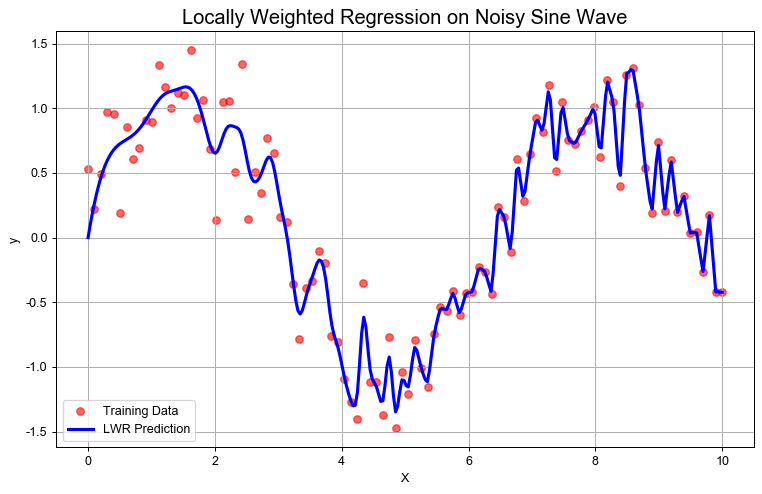

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.preprocessing import PolynomialFeatures

# 用于构建权重矩阵
def get_weights(query_point, X, tau):
    m = X.shape[0]
    weights = np.exp(-np.sum((X - query_point)**2, axis=1) / (2 * tau**2))
    return np.diag(weights)

# 局部加权回归主函数
def locally_weighted_regression(X, y, tau, query_points):
    m, n = X.shape
    y_preds = []

    for q in query_points:
        W = get_weights(q, X, tau)
        XTWX = X.T @ W @ X
        if np.linalg.det(XTWX) == 0:
            theta = np.linalg.pinv(XTWX) @ X.T @ W @ y
        else:
            theta = np.linalg.inv(XTWX) @ X.T @ W @ y
        y_pred = q @ theta
        y_preds.append(y_pred)
    return np.array(y_preds)

# 构造数据
np.random.seed(0)
X = np.linspace(0, 10, 100)
y = np.sin(X) + 0.3 * np.random.randn(100)

# 多项式特征
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X.reshape(-1, 1))

# 查询点用于可视化预测
query_points = np.linspace(0, 10, 300).reshape(-1, 1)
query_poly = poly.transform(query_points)

# 设置带宽
tau = 0.5
y_preds = locally_weighted_regression(X_poly, y, tau, query_poly)

# 可视化
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Training Data', alpha=0.6)
plt.plot(query_points, y_preds, color='blue', linewidth=2.5, label='LWR Prediction')
plt.title('Locally Weighted Regression on Noisy Sine Wave', fontsize=16)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### 可视化分析

![原文参考图，当前结果见代码输出](attachments/img_010.png)

**红色点**：原始观测数据（带噪声）

**蓝色线**：LWR 对数据的平滑拟合

**拟合能力非常强（局部适应性）**，由于每个点都“局部建模”，可以灵活拟合出变化快速或复杂的曲线。图中蓝线清晰地跟随了红点的起伏趋势。

**带宽** $\tau$ **控制灵敏度**，如果 $\tau$ 太小，模型会过拟合，表现为线条“过度震荡”。如果 $\tau$ 太大，模型就类似普通回归，拟合不够灵活。

可通过调节 tau 进行模型控制。

## 模型分析

### LWR 的优缺点总结

**优点**：

1. **高灵活性建模复杂关系**：数据为带噪的正弦波，明显具有非线性变化趋势。LWR 通过对每个预测点构建一个局部模型，有效拟合了每一个局部的非线性趋势，拟合结果平滑、自然。
2. **无需假设全局函数形式**：无需预先设定模型函数形状（如多项式阶数等），自适应地捕捉数据的局部特性，适合“无模型先验”的探索性分析。
3. **对异常点较为稳健（局部影响）**：离当前预测点较远的异常值对预测结果影响极小，不像全局回归那样易被极端点拖偏。
4. **可解释性强**：每一个预测都有明确的局部模型 $\theta$，有利于解释预测依据，尤其适合可解释性要求高的领域。

**缺点**：

1. **计算效率低，难以扩展到大规模数据**：每次预测都要重新求解一个加权线性回归问题（涉及矩阵求逆），对于大型数据集来说计算成本极高。
2. **不能离线训练或提前部署模型**：没有“统一模型参数”，无法像线性回归或神经网络那样，训练一次后快速预测；每次都得重新拟合。
3. **高维数据下性能下降（维度灾难）**：权重依赖于欧氏距离，在高维空间中，距离不再具有良好判别性，权重趋于一致，局部性失效。
4. **对带宽参数** $\tau$ **敏感**：$\tau$ 过小会过拟合，过大则退化为线性回归；需要交叉验证等方法精细调参。

### 与相似回归算法对比分析

| 算法 | 模型类型 | 是否全局模型 | 非线性建模能力 | 计算效率 | 训练方式 | 对异常点鲁棒性 | 可解释性 |
|-|-|-|-|-|-|-|-|
| 局部加权回归（LWR） | 非参数、局部 | 否 | 极强（局部拟合） | 低（每次预测都需拟合） | 无需训练，全预测时建模 | 高（异常点远离预测点时） | 高 |
| 线性回归 | 参数模型 | 是 | 弱 | 高 | 一次训练，快速预测 | 弱 | 高 |
| 多项式回归 | 参数模型 | 是 | 中（取决于阶数） | 中 | 一次训练，预测快 | 较弱 | 高 |
| K近邻回归（KNN） | 非参数、懒惰 | 否 | 强 | 中 | 无训练，预测查找邻居 | 较强 | 中 |
| 支持向量回归（SVR） | 参数模型 | 是 | 强 | 中 | 一次训练 | 强 | 较低 |
| 随机森林回归 | 集成模型 | 是 | 强 | 中 | 一次训练 | 强 | 较低 |
| 神经网络回归 | 参数模型 | 是 | 很强（深度网络） | 依规模而定 | 需大量训练 | 弱\~中（视结构而定） | 低 |

### LWR 的适用场景

你可以优先考虑使用局部加权回归，在以下几种场景中：

1. **数据量较小或中等，计算资源充足**：如科学实验、物理模拟等领域，样本数量有限，且拟合精度要求高。
2. **数据具有复杂、难以建模的局部变化**：如气象变化、医疗时间序列、光谱分析等，整体关系不可预测，但局部趋势明显。
3. **探索性数据分析，需要可解释性强的模型**：每次拟合一个局部模型，可以看到每次预测用到了哪些训练样本及其权重，对理解数据变化很有帮助。
4. **异常值干扰大的环境**：如传感器失真、网络丢包数据，LWR 的局部性降低了异常值影响。

### 何时应考虑其他算法替代

LWR 并不适用于所有情况。

在以下情况中，更应考虑其他模型：

1. **数据规模非常大（> 万级样本）**：推荐使用神经网络、随机森林、XGBoost 等高效全局模型。
2. **对预测效率要求极高（如实时系统）**：LWR 每次预测都要训练模型，延迟高。推荐线性回归、SVR、轻量神经网络。
3. **数据维度非常高（如文本、图像）**：高维空间中距离失去意义，局部性消失。推荐使用深度学习或核方法。
4. **任务目标不仅仅是预测，还包括模型压缩、部署、泛化等工程需求**：LWR 无法“存成模型”，不能部署到设备上。推荐使用支持参数冻结的模型。

## 总结

局部加权回归是一种非参数回归方法，适合在数据局部变化复杂、样本规模可控的场景中使用。但由于其“懒惰预测”和“高计算成本”的特性，当涉及高维度、大规模或需要模型部署时，应慎重考虑其他更高效的回归算法。